In [3]:
import numpy as np
import pandas as pd

df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [10]:
# dropping irrelevant columns implementing feature selection

df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

In [11]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
df.shape

(10000, 11)

# one hot encoding for categorical variables


In [13]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [14]:
df.shape

(10000, 12)

# Train test split and scaling 

In [15]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [31]:
X_test_trf.shape

(2000, 11)

# Building the network using tensorflow

In [17]:
# %pip install tensorflow

In [18]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [19]:
# creating a sequential model 
model = Sequential()

# adding the hidden layer 1 with 11 neurons
model.add(Dense(11,activation='sigmoid',input_dim=11))

# adding the hidden layer 2 with 11 neurons
model.add(Dense(11,activation='sigmoid'))

# adding the output layer with 1 neurons
model.add(Dense(1,activation='sigmoid'))

C:\Users\Shekhar Kumar\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# compiling my model 

model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [29]:
history = model.fit(X_train_trf,y_train,batch_size=50,epochs=30,verbose=1,validation_split=0.2)

Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7958 - loss: 0.4825 - val_accuracy: 0.7969 - val_loss: 0.4623
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7958 - loss: 0.4499 - val_accuracy: 0.7969 - val_loss: 0.4425
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7983 - loss: 0.4340 - val_accuracy: 0.8050 - val_loss: 0.4352
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8042 - loss: 0.4279 - val_accuracy: 0.8112 - val_loss: 0.4327
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8116 - loss: 0.4251 - val_accuracy: 0.8100 - val_loss: 0.4314
Epoch 6/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8103 - loss: 0.4237 - val_accuracy: 0.8081 - val_loss: 0.4308
Epoch 7/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8078 - loss: 0.4229 - val_accuracy: 0.8119 - val_loss: 0.4298
Epoch 8/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8114 - loss: 0.4218 - val_accuracy: 0.

In [32]:
model.layers[0].get_weights()

[array([[-0.07844703,  0.18171722,  0.08692054, -0.2532067 , -0.12136143,
          0.2032559 ,  0.31486037, -0.05721461, -0.14572063,  0.3090102 ,
          0.34569097],
        [ 0.16186881, -1.6014744 , -0.21658003,  2.3655758 ,  2.5028253 ,
         -1.6821247 , -2.366468  , -0.3898686 ,  0.19271515,  0.17602064,
          0.16069187],
        [-0.23494272,  0.0907862 , -0.07288177,  0.14803742,  0.0401243 ,
          0.24760275,  0.00849312, -0.1119013 ,  0.00458451,  0.22846134,
         -0.3395453 ],
        [-0.22943662,  0.150806  , -0.4901327 , -0.21422288,  0.22709282,
          0.09029561,  0.5319327 , -0.52021873, -0.3055618 ,  0.1441471 ,
          0.66589373],
        [-0.5543915 , -0.25288823, -0.3454728 ,  0.05576262,  0.3401878 ,
         -0.3162472 , -0.28422555, -2.6209645 ,  0.32157725,  0.0064006 ,
          0.45892987],
        [ 0.16142856, -0.11781369,  0.15597558,  0.07666963,  0.02169881,
         -0.07261457, -0.11232669,  0.01212128,  0.14204484, -0.5151540

In [33]:
model.layers[1].get_weights()

[array([[ 3.43722701e-01,  6.29200876e-01, -2.73841977e-01,
          1.19256498e-02,  1.06100714e+00,  1.16932702e+00,
          1.06759930e+00,  4.06269610e-01, -3.96695077e-01,
          4.91315275e-01,  3.92098993e-01],
        [ 1.77733988e-01, -8.95746499e-02, -1.57119855e-01,
         -1.00305170e-01,  2.32191429e-01, -2.92190234e-04,
          6.92935705e-01,  3.40291351e-01, -6.07559800e-01,
         -1.53443098e-01,  4.87452298e-01],
        [ 9.25624132e-01,  7.63255358e-01, -3.15739036e-01,
          5.90389788e-01,  1.49753630e-01,  1.84760485e-02,
          2.09331572e-01,  2.30664238e-01, -1.12457849e-01,
          7.23684788e-01,  6.21220052e-01],
        [-4.68746275e-01, -3.21917355e-01,  4.32077229e-01,
         -4.29242998e-01, -5.82013726e-02, -3.52719724e-01,
         -7.56000221e-01, -3.73709500e-01,  1.05630302e+00,
         -9.60587859e-02, -9.90414977e-01],
        [-3.71137142e-01, -3.85694027e-01,  2.93440372e-01,
         -9.92445648e-01, -7.01453209e-01, -

In [34]:
model.layers[2].get_weights()

[array([[-0.9196587 ],
        [-0.6003021 ],
        [ 0.9144907 ],
        [-0.42884195],
        [-0.69121695],
        [-0.32032418],
        [-0.6814342 ],
        [-0.9522809 ],
        [ 0.9746149 ],
        [-0.36518782],
        [-0.730679  ]], dtype=float32),
 array([0.0773771], dtype=float32)]

In [35]:
y_log = model.predict(X_test_trf)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [36]:
y_log

array([[0.2419117 ],
       [0.38060114],
       [0.19911496],
       ...,
       [0.10609002],
       [0.11212685],
       [0.2224291 ]], shape=(2000, 1), dtype=float32)

In [38]:
X_test.shape

(2000, 11)

In [41]:
y_pred = np.where(y_log > 0.5 , 1 , 0)

In [42]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [43]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)


0.8505

In [44]:
import matplotlib.pyplot as plt

history.history

{'accuracy': [0.7957812547683716,
  0.7957812547683716,
  0.7982812523841858,
  0.8042187690734863,
  0.8115624785423279,
  0.8103125095367432,
  0.807812511920929,
  0.8114062547683716,
  0.8134375214576721,
  0.8134375214576721,
  0.8157812356948853,
  0.8168749809265137,
  0.8187500238418579,
  0.8187500238418579,
  0.8201562762260437,
  0.821093738079071,
  0.8228124976158142,
  0.8235937356948853,
  0.8253124952316284,
  0.8259375095367432,
  0.828906238079071,
  0.831250011920929,
  0.8334375023841858,
  0.8337500095367432,
  0.8362500071525574,
  0.839062511920929,
  0.8387500047683716,
  0.8395312428474426,
  0.83984375,
  0.8423437476158142],
 'loss': [0.48245319724082947,
  0.44985127449035645,
  0.43404141068458557,
  0.4279034435749054,
  0.4251216650009155,
  0.42372429370880127,
  0.42289578914642334,
  0.42180129885673523,
  0.4208737313747406,
  0.41987448930740356,
  0.4186389148235321,
  0.4176745116710663,
  0.41623443365097046,
  0.4148746728897095,
  0.413338303565

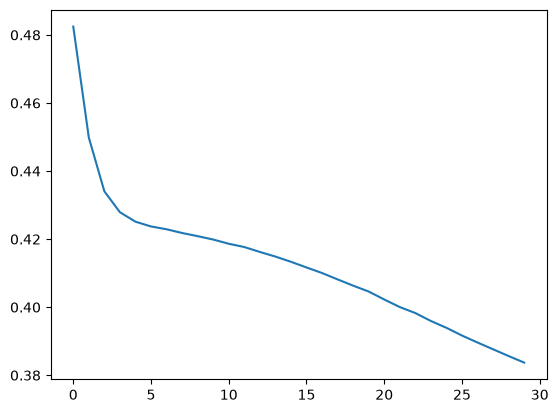

In [46]:
plt.plot(history.history['loss'])

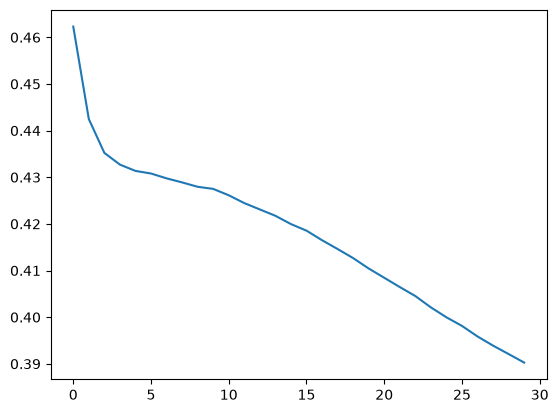

In [47]:
plt.plot(history.history['val_loss'])

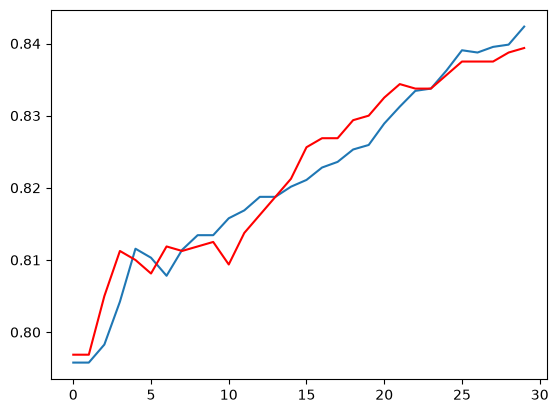

In [54]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'],color ='r')